# Notebook 11: Uncertainty Quantification — Bootstrap & Profile Likelihood

**Goal:** Understand and visualise the two uncertainty methods in `phoscrosstalk.posterior`.

This notebook is **educational and uses synthetic data** — actual runs are computationally expensive.

## 1. Why Uncertainty Quantification?

ODE models often suffer from **structural or practical non-identifiability**:

- *Structural*: Multiple θ give identical trajectories (e.g., k_on/k_off ratio).
- *Practical*: Data are too noisy or sparse to distinguish nearby parameter values.

Without UQ, a single best-fit θ gives a false sense of precision. UQ reveals which parameters are well-constrained and which are not.

## 2. Two Methods: Residual Bootstrap & Profile Likelihood

### 2a. Residual Bootstrap

1. Simulate at `theta_best` → compute residuals `r_i = y_obs_i - y_sim_i`
2. Resample residuals (case or parametric) → build perturbed data `y* = y_sim + r*`
3. Re-optimise from `theta_best ± jitter` → collect sample `theta_b`
4. Repeat `n_bootstrap` times → empirical distribution `{θ_b}_{b=1..B}`
5. Compute mean, std, 95% CI per parameter

### 2b. Profile Likelihood

Fix parameter `θ_i` at grid values `{g_1,…,g_P}`, re-optimise all others, record loss:

$$\mathcal{L}_{\mathrm{profile}}(\theta_i = g) = \min_{\theta_{\neq i}} \mathcal{L}(\theta_i=g,\, \theta_{\neq i})$$

| Profile shape | Interpretation |
|---|---|
| Sharp parabola | Well-identifiable |
| Flat | Structurally non-identifiable |
| Monotone (hits boundary) | Boundary-constrained |

## 3. `[posterior]` Config Section

```toml
[posterior]
enabled                  = true
method                   = "both"        # "bootstrap", "profile", or "both"
n_bootstrap              = 100
bootstrap_residual_mode  = "case"        # "case" or "parametric"
bootstrap_max_steps      = 200
profile_params           = 12
profile_points           = 21
profile_grid_fraction    = 1.0
```

**Outputs** in `outdir/uncertainty/`:

| File | Contents |
|---|---|
| `bootstrap_samples.npz` | θ array `(n_bootstrap, n_params)` |
| `bootstrap_summary.tsv` | mean, std, CI_low, CI_high per parameter |
| `profile_likelihood.npz` | profile loss per profiled parameter |
| `profile_likelihood_plots/` | PNG plots |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(42)
print("Setup complete.")

Setup complete.


In [2]:
from phoscrosstalk.config import ModelDims
from phoscrosstalk.data_loader import (
    load_site_data, load_rna_data, load_kinase_site_matrix,
    load_tf_network, build_tf_prot_weights, apply_scaling, row_normalize,
)
from phoscrosstalk.optimization import create_bounds, build_parameter_labels
from phoscrosstalk.weighting import build_weight_matrices
from phoscrosstalk.derived_rates import make_k_act_fn, make_s_prod_fn
from phoscrosstalk.simulation import simulate
from phoscrosstalk.mechanisms import decode_theta, compute_prev_site_idx

TIMEPOINTS = list(range(1, 15))   # 14 time points x1..x14

# Phosphosite + protein abundance
sites, proteins, site_prot_idx, positions, t_phos, Y, A_data, A_proteins = \
    load_site_data(str(SAMPLE_DIR / "protephospho.csv"), TIMEPOINTS)

K = len(proteins);  N = len(sites);  T = len(t_phos)
print(f"proteins : {proteins}  (K={K})")
print(f"sites    : {sites}  (N={N})")
print(f"t_phos   : {t_phos}  (T={T})")

# mRNA
gene_ids, t_rna, rna_matrix = load_rna_data(str(SAMPLE_DIR / "mrna.csv"), timepoints=TIMEPOINTS)
print(f"gene_ids : {gene_ids}")

# Kinase-site matrix
K_site_kin, kinases = load_kinase_site_matrix(str(SAMPLE_DIR / "kinase_sites.tsv"), sites)
M = len(kinases)
kin_to_prot_idx = np.array([proteins.index(k) for k in kinases], dtype=int)
print(f"kinases  : {kinases}  (M={M})")

# TF network
tf_net = load_tf_network(str(SAMPLE_DIR / "tf_mrna.csv"), gene_ids=gene_ids)
tf_prot_weights = build_tf_prot_weights(tf_net, gene_ids, proteins)

# Scale data
P_scaled, _, _ = apply_scaling(Y)
A_scaled, _, _ = apply_scaling(A_data)
dims = ModelDims(K=K, M=M, N=N)

# Auxiliary matrices
Cg = np.zeros((N, N));  Cl = np.zeros((N, N))
R_kin = row_normalize(K_site_kin.T);  L_alpha = np.zeros((M, M))
receptor_mask_prot = np.zeros(K);  receptor_mask_kin = np.zeros(M)

# Rate closures
k_act_fn  = make_k_act_fn(t_rna=t_rna, rna_data=rna_matrix,
                           tf_prot_weights=tf_prot_weights, K=K)
s_prod_fn = make_s_prod_fn(t_protein=t_phos, Y_data=P_scaled,
                            R_kin_site=R_kin,
                            kin_to_prot_idx=kin_to_prot_idx, K=K, M=M)

# Parameter bounds + names
xl, xu, n_params = create_bounds(K, M, N)
theta_names = build_parameter_labels(K, M, N)
print(f"n_params = {n_params}")

# Load or synthesise theta_best
theta_path = OUTPUT_DIR / "theta_best.npy"
if theta_path.exists():
    theta_best = np.load(theta_path)
    print(f"Loaded theta_best: shape={theta_best.shape}")
else:
    theta_best = rng.uniform(xl, xu)
    print(f"Synthetic theta_best: shape={theta_best.shape}")

proteins : ['EGFR', 'ERBB2', 'MET']  (K=3)
sites    : ['EGFR_Y1068', 'EGFR_S1173', 'EGFR_T992', 'MET_Y1068', 'MET_S1173', 'MET_T992', 'ERBB2_Y1068', 'ERBB2_S1173', 'ERBB2_T992']  (N=9)
t_phos   : [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]  (T=14)
gene_ids : ['EGFR', 'MET', 'ERBB2']
kinases  : ['EGFR', 'MET']  (M=2)
n_params = 27
Loaded theta_best: shape=(27,)


## 4. Synthetic Bootstrap Samples

We generate `n_bootstrap=50` synthetic samples to illustrate the UQ workflow. Each sample mimics a bootstrap refit by drawing from a normal centred on `theta_best`.

In [3]:
n_bootstrap = 50
# ~5-15% noise per parameter
noise_scale = np.abs(theta_best) * rng.uniform(0.05, 0.15, size=n_params)
bootstrap_samples = theta_best[None, :] + rng.normal(0, noise_scale, size=(n_bootstrap, n_params))
print(f'Bootstrap samples shape: {bootstrap_samples.shape}')  # (50, n_params)

ci_low  = np.percentile(bootstrap_samples, 2.5,  axis=0)
ci_high = np.percentile(bootstrap_samples, 97.5, axis=0)
ci_width = ci_high - ci_low

summary_df = pd.DataFrame({
    'parameter': theta_names,
    'theta_best': theta_best,
    'bs_mean':  bootstrap_samples.mean(axis=0),
    'bs_std':   bootstrap_samples.std(axis=0),
    'ci_low':   ci_low,
    'ci_high':  ci_high,
    'ci_width': ci_width,
})
print(summary_df.head(10).to_string(index=False))

Bootstrap samples shape: (50, 27)
     parameter  theta_best    bs_mean   bs_std     ci_low   ci_high  ci_width
log_k_deact[0]   -3.882965  -3.903922 0.526998  -4.704877 -2.864330  1.840547
log_k_deact[1]   -0.561469  -0.557510 0.053085  -0.657744 -0.452687  0.205057
log_k_deact[2]   -2.044850  -2.050153 0.272331  -2.627504 -1.623037  1.004467
  log_d_deg[0]   -9.076234  -8.977815 1.102882 -10.769126 -6.825045  3.944081
  log_d_deg[1]   -8.265193  -8.261809 0.565792  -9.231219 -7.334145  1.897074
  log_d_deg[2]   -2.061271  -2.103240 0.309198  -2.608870 -1.361968  1.246902
    log_beta_g  -11.446522 -11.490713 1.353527 -13.849355 -8.872529  4.976826
    log_beta_l   -1.155972  -1.178253 0.136699  -1.464436 -0.897246  0.567190
  log_alpha[0]    0.900790   0.898011 0.052444   0.793474  0.990340  0.196866
  log_alpha[1]   -1.372790  -1.361553 0.132191  -1.600688 -1.150707  0.449981


## 5. Bootstrap Histograms for Selected Parameters

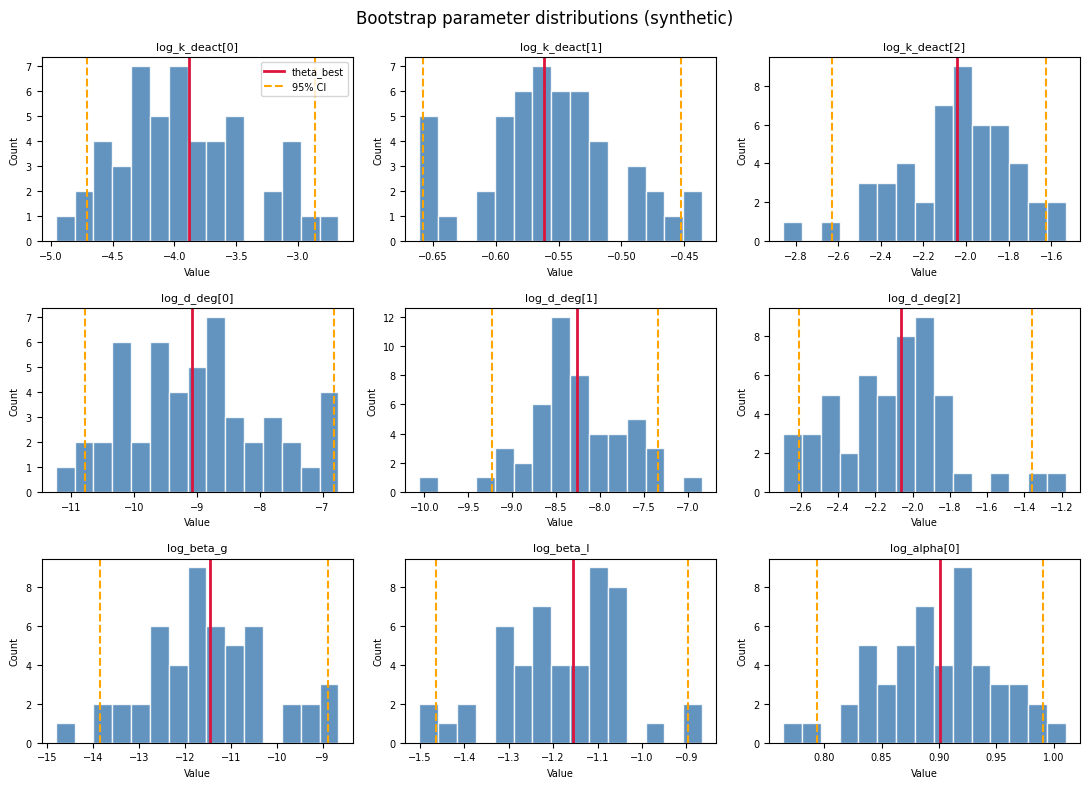

Saved: 11_bootstrap_distributions.png


In [4]:
n_show = min(9, n_params)
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
for ax, i in zip(axes.flat, range(n_show)):
    ax.hist(bootstrap_samples[:, i], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(theta_best[i], color='crimson', lw=2, label='theta_best')
    ax.axvline(ci_low[i],  color='orange', lw=1.5, ls='--')
    ax.axvline(ci_high[i], color='orange', lw=1.5, ls='--', label='95% CI')
    ax.set_title(theta_names[i], fontsize=8)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
plt.suptitle('Bootstrap parameter distributions (synthetic)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_bootstrap_distributions.png', dpi=120)
plt.show()
print('Saved: 11_bootstrap_distributions.png')

## 6. CI Width Bar Chart

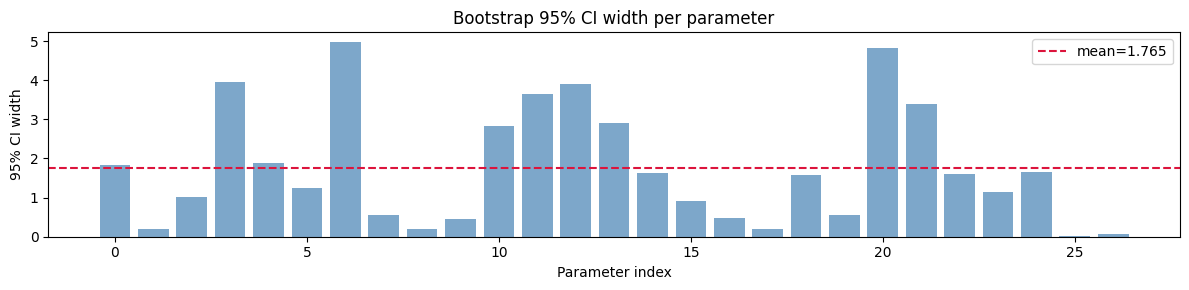

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(np.arange(n_params), ci_width, color='steelblue', alpha=0.7)
ax.set_xlabel('Parameter index')
ax.set_ylabel('95% CI width')
ax.set_title('Bootstrap 95% CI width per parameter')
ax.axhline(ci_width.mean(), color='crimson', ls='--', label=f'mean={ci_width.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_ci_widths.png', dpi=120)
plt.show()

## 7. Synthetic Profile Likelihood Curves

Four shapes illustrate the identifiability interpretation.

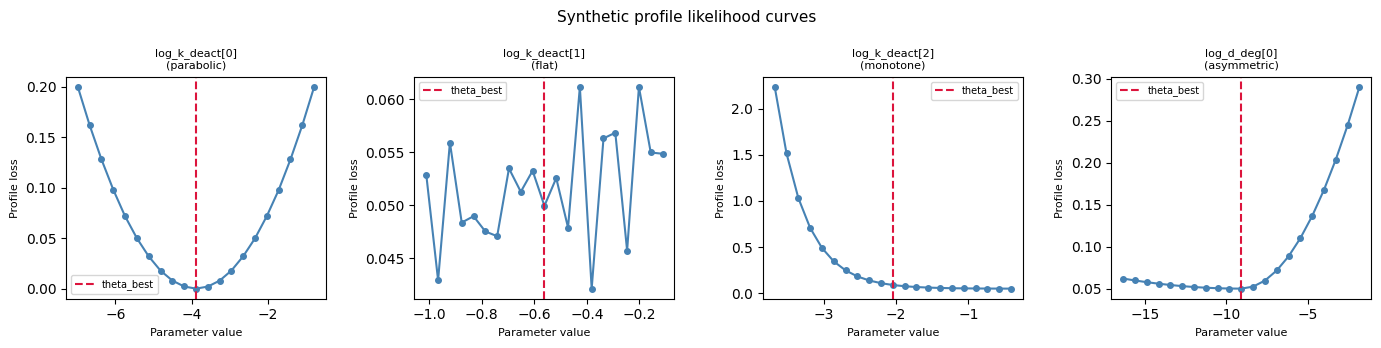

Saved: 11_profile_likelihood.png


In [6]:
profile_points = 21

def synthetic_profile(kind, theta_i, grid_fraction=0.8):
    half = max(abs(theta_i) * grid_fraction, 1e-3)
    grid = np.linspace(theta_i - half, theta_i + half, profile_points)
    z = (grid - theta_i) / (half / 2)
    if kind == 'parabolic':
        loss = 0.05 * z**2 + 0.001 * rng.normal(0, 0.1, profile_points)
    elif kind == 'flat':
        loss = 0.05 + 0.01 * rng.normal(0, 0.5, profile_points)
    elif kind == 'monotone':
        loss = 0.05 + 0.04 * np.exp(-2 * z)
    else:  # asymmetric
        loss = 0.05 + 0.03 * np.where(z < 0, 0.1 * z**2, 2.0 * z**2)
    return grid, np.clip(loss, 0, None)

profile_cases = [
    ('parabolic',  theta_names[0], theta_best[0]),
    ('flat',       theta_names[1], theta_best[1]),
    ('monotone',   theta_names[2], theta_best[2]),
    ('asymmetric', theta_names[3], theta_best[3]),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (kind, name, val) in zip(axes, profile_cases):
    grid, loss = synthetic_profile(kind, val)
    ax.plot(grid, loss, 'o-', color='steelblue', ms=4)
    ax.axvline(val, color='crimson', lw=1.5, ls='--', label='theta_best')
    ax.set_title(f'{name}\n({kind})', fontsize=8)
    ax.set_xlabel('Parameter value', fontsize=8)
    ax.set_ylabel('Profile loss', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Synthetic profile likelihood curves', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_profile_likelihood.png', dpi=120)
plt.show()
print('Saved: 11_profile_likelihood.png')

## 8. Non-Identifiability of Kinase Rates

When a kinase activation rate `kK_act_m` is **non-identifiable**:

- Its profile likelihood is flat → many values fit equally well
- Bootstrap CIs are very wide → resampling never pins down the value
- Possible causes: kinase has no direct substrate sites in `K_site_kin`, signal confounded with another kinase, or data lacks variance to excite that dimension

**Remedies:** Add kinase-specific data, reduce model dimensionality, or apply stronger priors via `w_reg`.

In [7]:
summary_df.to_csv(OUTPUT_DIR / '11_bootstrap_summary.tsv', sep='\t', index=False)
print('Saved: 11_bootstrap_summary.tsv')
print('\nTop 5 widest CIs:')
print(summary_df.nlargest(5, 'ci_width')[['parameter','theta_best','ci_width']].to_string(index=False))

Saved: 11_bootstrap_summary.tsv

Top 5 widest CIs:
      parameter  theta_best  ci_width
     log_beta_g  -11.446522  4.976826
   log_k_off[6]   -8.687566  4.821883
   log_d_deg[0]   -9.076234  3.944081
log_kK_deact[0]   -8.298628  3.901040
  log_kK_act[1]   -8.001550  3.661637
